      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9
(200, 4)
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


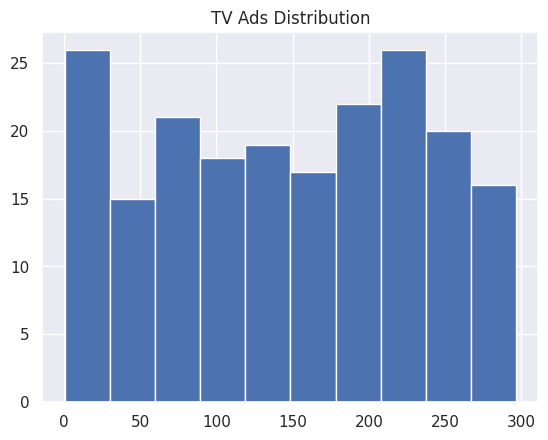

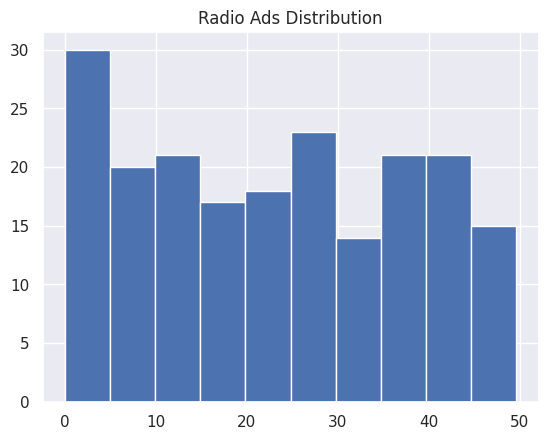

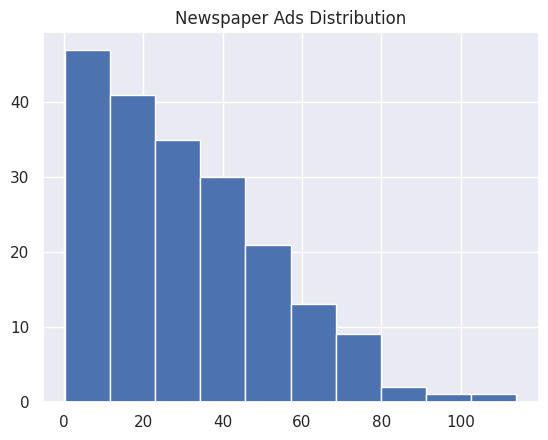

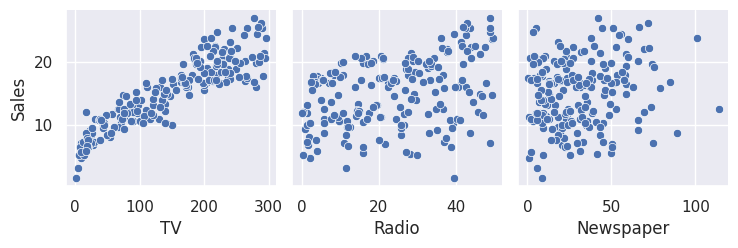

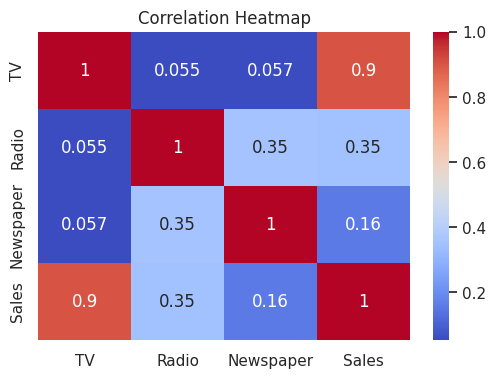

Accuracy (R2 Score): 88.78%
MAE: 1.3799080402719879
MSE: 3.626473038410332
Intercept: 5.022730805826269
Coefficients: [ 0.05223455  0.10672463 -0.00120158]


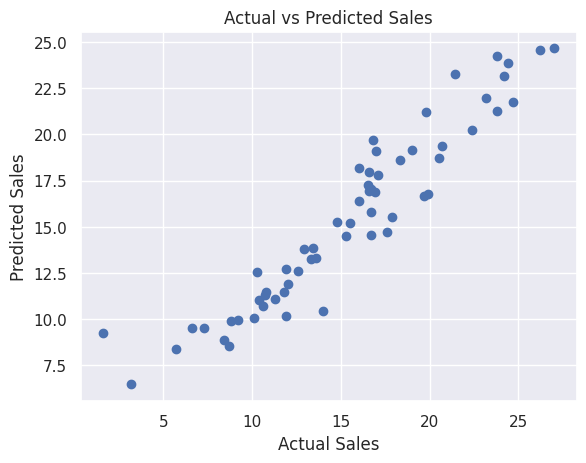

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset
data = pd.read_csv("advertising.csv")

# Basic Info
print(data.head())
print(data.shape)
print(data.describe())
print(data.isnull().sum())

# Visualization
sns.set()

# Histograms
data['TV'].hist()
plt.title("TV Ads Distribution")
plt.show()

data['Radio'].hist()
plt.title("Radio Ads Distribution")
plt.show()

data['Newspaper'].hist()
plt.title("Newspaper Ads Distribution")
plt.show()

# Pairplot
sns.pairplot(data, x_vars=['TV','Radio','Newspaper'], y_vars='Sales', kind='scatter')
plt.show()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Features & Target
X = data[['TV', 'Radio', 'Newspaper']]   # you can also try removing Newspaper
Y = data['Sales']

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=3)

# Model Training
model = LinearRegression()
model.fit(X_train, Y_train)

# Predictions
prediction = model.predict(X_test)

# Model Evaluation
r2_score = model.score(X_test, Y_test) * 100
mae = mean_absolute_error(Y_test, prediction)
mse = mean_squared_error(Y_test, prediction)

print(f"Accuracy (R2 Score): {r2_score:.2f}%")
print(f"MAE: {mae}")
print(f"MSE: {mse}")

# Model Parameters
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Actual vs Predicted Plot
plt.scatter(Y_test, prediction)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()